#  Clasificación de Imágenes con Redes Neuronales Artificiales (MLP)

##  Introducción

En el contexto del aprendizaje automático, las redes neuronales artificiales representan una de las herramientas más relevantes para la resolución de problemas de clasificación, especialmente en el área de visión computacional.

En este trabajo se aborda el problema de **clasificación de imágenes** utilizando el dataset **CIFAR-10**, el cual contiene 60.000 imágenes en color de tamaño 32x32 píxeles, distribuidas en 10 clases distintas (como aviones, autos, animales, entre otros).

El objetivo principal es diseñar, implementar y evaluar una **red neuronal multicapa (MLP)** capaz de aprender patrones a partir de los datos y clasificar correctamente nuevas imágenes.

---

##  Objetivos

###  Objetivo General
Desarrollar un modelo de red neuronal artificial para resolver un problema de clasificación de imágenes, evaluando su desempeño y capacidad de generalización.

###  Objetivos Específicos

- Cargar y preprocesar correctamente el dataset CIFAR-10  
- Implementar un modelo base de red neuronal (MLP)  
- Aplicar técnicas de optimización como regularización y dropout  
- Analizar el impacto de hiperparámetros (learning rate, batch size, épocas)  
- Comparar funciones de activación (ReLU vs Sigmoid)  
- Evaluar el modelo mediante métricas como accuracy, precision, recall y F1-score  
- Interpretar los resultados mediante gráficos y análisis cualitativo  

---

##  Enfoque del trabajo

El desarrollo del proyecto se organiza en distintas etapas:

1. **Carga y preprocesamiento de datos**
2. **Diseño de modelos (base y optimizado)**
3. **Entrenamiento y ajuste de hiperparámetros**
4. **Evaluación cuantitativa del modelo**
5. **Análisis cualitativo de resultados**
6. **Comparación entre configuraciones**

---

##  Consideraciones técnicas

Se utiliza **TensorFlow/Keras** como framework principal para la implementación del modelo, permitiendo trabajar de forma eficiente con redes neuronales y facilitar la experimentación.

Además, se aplican técnicas como:

- Normalización y estandarización de datos  
- Regularización L2  
- Dropout  
- Batch Normalization  

Estas técnicas buscan mejorar la estabilidad del entrenamiento y la capacidad de generalización del modelo.

---

##  Alcance

Este trabajo se centra en el uso de redes neuronales completamente conectadas (**MLP**), lo que permite comprender los fundamentos del aprendizaje profundo. Sin embargo, también se analizarán sus limitaciones frente a problemas de visión computacional más complejos.

In [27]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Cargar CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()



class_names = ['avión', 'auto', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

/tmp/ipykernel_160403/2315276292.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


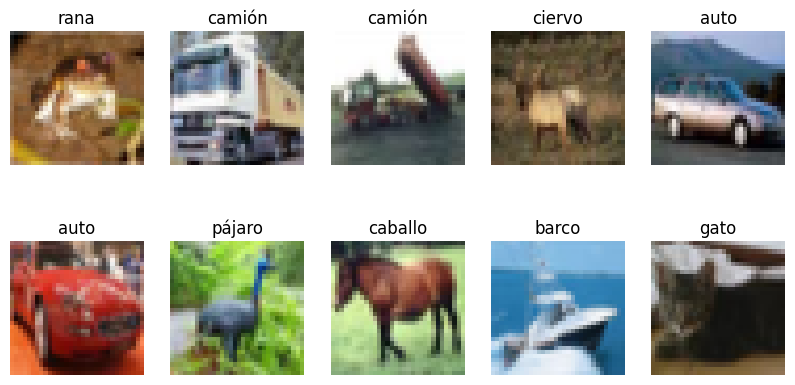

In [28]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.show()

Se normalizaron los datos al rango [0,1] para reducir la magnitud de los valores de entrada, lo que permite que el algoritmo de descenso del gradiente funcione de manera más eficiente y estable.
Posteriormente, se aplicó estandarización utilizando la media y desviación estándar del conjunto de entrenamiento, con el objetivo de centrar los datos en torno a cero y escalar su variabilidad.
Esto mejora la convergencia del modelo, evita problemas de saturación en las funciones de activación y facilita un aprendizaje más rápido y estable.

In [6]:
# Normalizar + centrar (MUY importante)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

mean = x_train.mean(axis=0)
std = x_train.std(axis=0) + 1e-7

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

## Modelo Base (MLP sin regularización)

En esta etapa se implementa un **Perceptrón Multicapa (MLP)** como modelo base para la clasificación del dataset CIFAR-10. Este modelo servirá como referencia para comparar posteriormente el impacto de técnicas de optimización y regularización.

---

###  Estructura del modelo

El modelo está compuesto por las siguientes capas:

- **Capa de entrada (Flatten):**  
  Convierte cada imagen de tamaño 32x32x3 en un vector de 3072 valores. Esto es necesario porque las capas densas trabajan con datos unidimensionales.

- **Capas ocultas (Dense):**  
  Se utilizan tres capas densas con 512, 256 y 128 neuronas respectivamente.  
  Cada neurona aplica la operación:

  $$ y = f(Wx + b) $$

  donde:
  - **W** representa los pesos  
  - **b** representa el bias  
  - **f** es la función de activación (ReLU)

- **Función de activación (ReLU):**  
  Se utiliza ReLU (Rectified Linear Unit) porque permite evitar el problema del gradiente desvanecido y mejora la convergencia del modelo.

- **Capa de salida:**  
  Se utiliza una capa con 10 neuronas (una por clase) y función **softmax**, que permite obtener probabilidades para cada categoría.

---

###  Configuración del modelo

- **Optimizador:** Adam  
  Se utiliza debido a su capacidad de ajustar automáticamente la tasa de aprendizaje durante el entrenamiento.

- **Tasa de aprendizaje:** 0.001  
  Permite un aprendizaje relativamente rápido en las primeras etapas.

- **Función de pérdida:** sparse_categorical_crossentropy  
  Adecuada para problemas de clasificación multiclase cuando las etiquetas están codificadas como enteros.

- **Métrica:** accuracy  
  Permite evaluar el porcentaje de predicciones correctas.

---

###  Proceso de entrenamiento

- **Epochs:** 25  
  Número de iteraciones completas sobre el conjunto de entrenamiento.

- **Batch size:** 64  
  Define la cantidad de datos procesados antes de actualizar los pesos. Este valor permite un equilibrio entre estabilidad y velocidad.

- **Validation split:** 0.2  
  Se reserva un 20% de los datos para validación, lo que permite evaluar la capacidad de generalización del modelo durante el entrenamiento.

---

###  Objetivo del modelo base

Este modelo no incluye técnicas de regularización, por lo que su principal propósito es:

- Servir como punto de comparación  
- Identificar problemas como overfitting  
- Evaluar el impacto de mejoras posteriores  

---

###  Limitación esperada

Debido a la ausencia de regularización, es esperable que el modelo:

- Obtenga buena precisión en entrenamiento  
- Pero menor rendimiento en validación  
- Lo que indica **sobreajuste (overfitting)**  

---

###  Conclusión

Este modelo base permite establecer una línea inicial de rendimiento, sobre la cual se aplicarán mejoras mediante técnicas como regularización, ajuste de hiperparámetros y optimización del entrenamiento.

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Definición del modelo Base (Sin Regularización)
model_base = models.Sequential([
    # Capa de entrada: aplana la imagen 32x32x3 a 3072 píxeles
    layers.Flatten(input_shape=(32, 32, 3)),

    # Capas densas con alta capacidad (sin Dropout ni L2)
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'), # Capa intermedia adicional para profundidad

    # Capa de salida: 10 neuronas (una por clase)
    layers.Dense(10, activation='softmax')
])

# Compilación
model_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
history_base = model_base.fit(
    x_train, y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.2, # 20% para monitorear la generalización
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.3848 - loss: 1.7535 - val_accuracy: 0.4144 - val_loss: 1.6427
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.4621 - loss: 1.5207 - val_accuracy: 0.4549 - val_loss: 1.5546
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.5010 - loss: 1.4144 - val_accuracy: 0.4822 - val_loss: 1.4774
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.5298 - loss: 1.3335 - val_accuracy: 0.4836 - val_loss: 1.4767
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.5517 - loss: 1.2659 - val_accuracy: 0.4941 - val_loss: 1.4613
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.5755 - loss: 1.1948 - val_accuracy: 0.5037 - val_loss: 1.4412
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.5963 - loss: 1.1405 - val_accuracy: 0.5064 - val_loss: 1.4501
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.6154 - loss: 1.0818 - 

##  Análisis del Modelo sin Regularización

Las curvas de aprendizaje del modelo sin regularización evidencian una **incapacidad crítica para generalizar**, mostrando una divergencia significativa entre el rendimiento en entrenamiento y validación.

---

##  1. Gráfica de Accuracy: Divergencia de rendimiento

###  Entrenamiento
- Crecimiento sostenido hasta superar el **85% de accuracy**  
- Indica alta capacidad de aprendizaje del modelo  

###  Validación
- Se estanca rápidamente alrededor de la **época 5**  
- Se mantiene cerca del **50% de accuracy**  

---

###  Interpretación

La diferencia superior a **30 puntos porcentuales** entre entrenamiento y validación indica un claro caso de:

>  **Sobreajuste (Overfitting)**

El modelo:
- Aprende patrones específicos del conjunto de entrenamiento  
- No logra generalizar a datos nuevos  
- Memoriza ruido en lugar de aprender características relevantes  

---

##  2. Gráfica de Loss: Comportamiento tipo “U-Turn”

Se observa un patrón crítico en la función de pérdida:

###  Loss entrenamiento
- Disminuye de forma constante  
- Se aproxima a valores cercanos a cero  

###  Loss validación
- Disminuye inicialmente  
- Luego comienza a **aumentar a partir de la época 5**  

---

###  Interpretación técnica

Este comportamiento indica que:

- El modelo se vuelve **excesivamente confiado**  
- Aumenta el error en datos no vistos  
- Se ajusta demasiado a los datos de entrenamiento  

 Este fenómeno es característico del **overfitting severo**.

---

##  3. Conclusión del modelo base

Este modelo cumple un rol clave como punto de referencia, ya que permite evidenciar:

### Falla estructural
- Las redes densas sin regularización tienden a memorizar  
- No existe control sobre la complejidad del modelo  

---


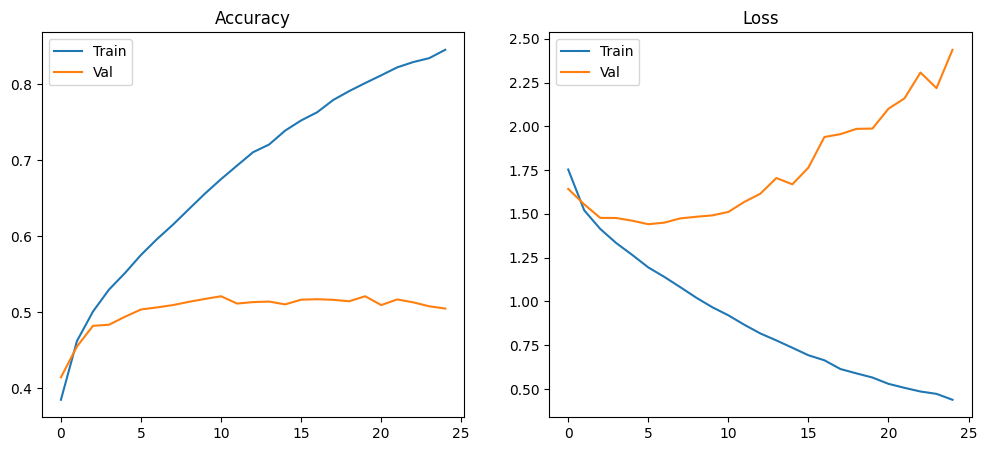

In [19]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_base.history['accuracy'], label='Train')
plt.plot(history_base.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_base.history['loss'], label='Train')
plt.plot(history_base.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

##  Modelo Regularizado (MLP optimizado)

En esta etapa se implementa un **Perceptrón Multicapa (MLP) con técnicas de regularización**, con el objetivo de mejorar la capacidad de generalización del modelo y reducir el sobreajuste observado en el modelo base.

---

###  Estructura del modelo

El modelo está compuesto por las siguientes capas:

- **Capa de entrada (Flatten):**  
  Convierte la imagen de tamaño 32x32x3 en un vector de 3072 características para su procesamiento.

---

- **Capa oculta 1:**
  - 512 neuronas  
  - Activación **ReLU**  
  - Inicialización **He Normal** (optimizada para ReLU)  
  - Regularización **L2 (0.001)**  
  - **BatchNormalization** → estabiliza la distribución de activaciones  
  - **Dropout (0.5)** → reduce el sobreajuste  

---

- **Capa oculta 2:**
  - 256 neuronas  
  - Activación **ReLU**  
  - Inicialización **He Normal**  
  - Regularización **L2 (0.001)**  
  - **BatchNormalization**  
  - **Dropout (0.4)**  

---

- **Capa oculta 3:**
  - 128 neuronas  
  - Activación **ReLU**  
  - **BatchNormalization**  
  - **Dropout (0.3)**  

---

- **Capa de salida:**
  - 10 neuronas  
  - Activación **Softmax**  
  - Permite obtener probabilidades para cada clase  

---

###  Configuración del modelo

- **Optimizador:** Adam  
  Se utiliza por su eficiencia en problemas de deep learning.

- **Tasa de aprendizaje:** 0.0002  
  Se reduce respecto al modelo base para lograr un aprendizaje más estable.

- **Función de pérdida:** sparse_categorical_crossentropy  
  Adecuada para clasificación multiclase con etiquetas enteras.

- **Métrica:** accuracy  

---

###  Proceso de entrenamiento

- **Epochs:** 100  
  Se aumentan debido a que el uso de regularización y dropout ralentiza el aprendizaje.

- **Batch size:** 128  
  Permite obtener gradientes más estables.

- **Validation split:** 0.2  
  Se utiliza para evaluar la generalización del modelo durante el entrenamiento.

---

###  Técnicas de optimización aplicadas

- **Regularización L2:**  
  Penaliza pesos grandes, evitando que el modelo memorice los datos.

- **Dropout:**  
  Desactiva neuronas aleatoriamente durante el entrenamiento, mejorando la robustez del modelo.

- **BatchNormalization:**  
  Reduce el desplazamiento interno de las activaciones, acelerando la convergencia.

---

###  Callbacks utilizados

- **EarlyStopping:**  
  Detiene el entrenamiento cuando la pérdida de validación deja de mejorar, evitando sobreentrenamiento.

- **ReduceLROnPlateau:**  
  Reduce la tasa de aprendizaje cuando el modelo se estanca, permitiendo un ajuste más fino.

---

###  Objetivo del modelo

- Reducir el overfitting observado en el modelo base  
- Mejorar la capacidad de generalización  
- Obtener un mejor equilibrio entre entrenamiento y validación  

---

###  Comportamiento esperado

- Menor diferencia entre accuracy de entrenamiento y validación  
- Entrenamiento más lento pero más estable  
- Mejor rendimiento en datos no vistos  

---

###  Conclusión

El uso de técnicas de regularización como L2, Dropout y BatchNormalization permite mejorar significativamente la estabilidad del modelo y su capacidad de generalización, obteniendo un mejor desempeño en comparación con el modelo base.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

model_reg_final = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),

    # Capa 1: Aumentamos Dropout para frenar el overfitting inicial
    layers.Dense(512,
                 activation='relu',
                 kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(0.001)), # L2 más fuerte
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Capa 2: Reducimos complejidad
    layers.Dense(256,
                 activation='relu',
                 kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Capa 3: Capa más delgada para forzar abstracción
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Salida
    layers.Dense(10, activation='softmax')
])

# Bajamos ligeramente el learning rate inicial para un aprendizaje más estable
model_reg_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2, # Reducción más drástica para "afinar" al final
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

history = model_reg_final.fit(
    x_train, y_train,
    epochs=100,
    batch_size=128, # Batch size más grande para gradientes más estables
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.2507 - loss: 3.8737 - val_accuracy: 0.3784 - val_loss: 3.2452 - learning_rate: 2.0000e-04
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.3182 - loss: 3.4628 - val_accuracy: 0.4030 - val_loss: 3.0942 - learning_rate: 2.0000e-04
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.3492 - loss: 3.2377 - val_accuracy: 0.4310 - val_loss: 2.9305 - learning_rate: 2.0000e-04
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.3720 - loss: 3.0560 - val_accuracy: 0.4397 - val_loss: 2.7993 - learning_rate: 2.0000e-04
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.3897 - loss: 2.8873 - val_accuracy: 0.4563 - val_loss: 2.6590 - learning_rate: 2.0000e-04
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.4060 - loss: 2.7404 - val_accuracy: 0.4626 - val_loss: 2.5444 - learning_rate: 2.0000e-04
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 5

## Análisis del comportamiento del modelo regularizado

El modelo presenta un comportamiento de entrenamiento **estable y controlado**, evidenciado por el descenso progresivo de la función de pérdida (*loss*) tanto en el conjunto de entrenamiento como en el de validación.

El uso de técnicas como **Batch Normalization** y **Dropout** permitió estabilizar el proceso de aprendizaje, evitando oscilaciones bruscas y favoreciendo una convergencia más suave.

---

##  Estancamiento en la generalización

A partir de aproximadamente la época 48, tras la reducción de la tasa de aprendizaje, se observa que el **accuracy de validación se estabiliza en torno al 59%**, mientras que el accuracy de entrenamiento continúa aumentando hasta valores cercanos al 70%.

Esta diferencia entre ambas métricas evidencia la presencia de **sobreajuste moderado (overfitting)**, donde el modelo logra adaptarse cada vez mejor a los datos de entrenamiento, pero no mejora su desempeño sobre datos no vistos.

---

##  Diagnóstico de la arquitectura

La brecha entre el rendimiento en entrenamiento y validación sugiere que el modelo ha alcanzado un **límite en su capacidad de representación**.

Esto se explica por las características del modelo:

- Utiliza exclusivamente **capas densas (Dense)**  
- No aprovecha la **estructura espacial de las imágenes**  
- No captura patrones locales como bordes, texturas o formas  

Como resultado, el modelo tiende a **memorizar combinaciones de píxeles** en lugar de aprender representaciones más abstractas y generalizables.

---

##  Conclusión

El modelo logra un entrenamiento estable y presenta mejoras respecto al modelo base; sin embargo, su desempeño se encuentra limitado por la arquitectura utilizada.

A pesar del uso de técnicas de regularización, el modelo no logra superar el umbral cercano al **60% de accuracy en validación**, lo que indica una limitación estructural más que un problema de entrenamiento.




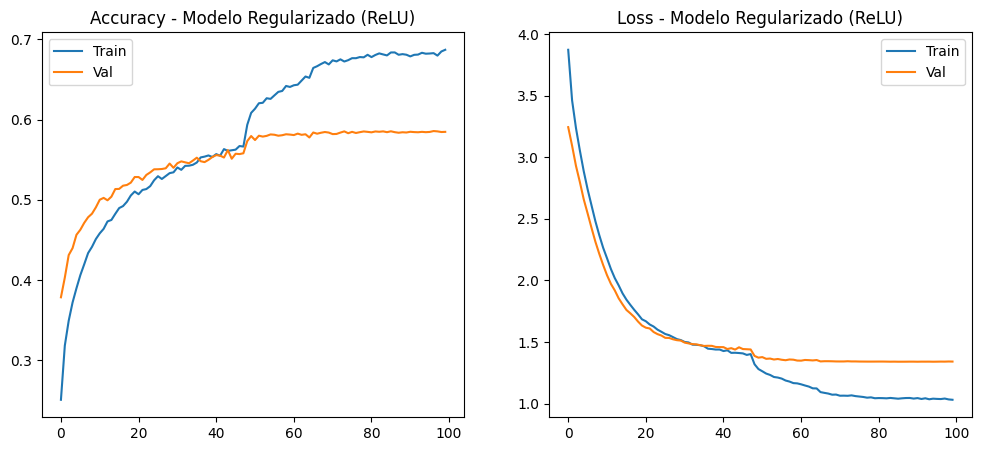

In [20]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy - Modelo Regularizado (ReLU)')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss - Modelo Regularizado (ReLU)')
plt.legend()

plt.show()

##  Modelo con función Sigmoide (MLP con regularización ligera)

En esta etapa se implementa un **Perceptrón Multicapa (MLP)** utilizando la función de activación **Sigmoide**, con el objetivo de analizar su comportamiento y compararlo con funciones modernas como ReLU.

---

###  Estructura del modelo

El modelo está compuesto por las siguientes capas:

- **Capa de entrada (Flatten):**  
  Convierte cada imagen de tamaño 32x32x3 en un vector de 3072 características para su procesamiento en capas densas.

- **Capas ocultas (Dense):**  
  Se utilizan dos capas densas con 128 y 64 neuronas respectivamente.  
  Cada neurona aplica la operación:

  $$ y = f(Wx + b) $$

  donde:
  - **W** representa los pesos  
  - **b** representa el bias  
  - **f** es la función de activación (**Sigmoid**)

- **Función de activación (Sigmoid):**  
  La función Sigmoide transforma los valores al rango (0,1), lo que permite interpretar las salidas como probabilidades.  
  Sin embargo, presenta el problema del **gradiente desvanecido**, especialmente en redes profundas.

- **Regularización L2:**  
  Se aplica una penalización a los pesos para evitar que crezcan excesivamente y mejorar la generalización del modelo.

- **Dropout:**  
  Se utiliza para desactivar aleatoriamente neuronas durante el entrenamiento, reduciendo el sobreajuste.

- **Capa de salida:**  
  Se utiliza una capa con 10 neuronas y función **softmax**, que permite clasificar en múltiples categorías.

---

###  Configuración del modelo

- **Optimizador:** Adam con `clipnorm=1.0`  
  Se utiliza Adam por su eficiencia, y se añade **clipping de gradiente** para evitar valores extremos durante el entrenamiento.

- **Tasa de aprendizaje:** 0.00005  
  Se reduce significativamente debido a la sensibilidad de la función Sigmoide.

- **Función de pérdida:** sparse_categorical_crossentropy  
  Adecuada para clasificación multiclase con etiquetas enteras.

- **Métrica:** accuracy  
  Permite medir el porcentaje de predicciones correctas.

---

### Proceso de entrenamiento

- **Epochs:** 50  
  Se aumentan las épocas debido a que Sigmoid aprende más lentamente.

- **Batch size:** 128  
  Permite mayor estabilidad en el cálculo del gradiente.

- **Validation split:** 0.2  
  Se reserva un 20% de los datos para evaluar la generalización.

- **Callbacks utilizados:**
  - **EarlyStopping:** detiene el entrenamiento si no hay mejora en validación.
  - **ReduceLROnPlateau:** reduce la tasa de aprendizaje si el modelo se estanca.

---

###  Objetivo del modelo

Este modelo se utiliza con fines comparativos para:

- Analizar el comportamiento de la función Sigmoide  
- Observar su impacto en la convergencia  
- Comparar su rendimiento con funciones como ReLU  

---

### Limitaciones esperadas

- Aprendizaje más lento  
- Menor precisión en comparación con ReLU  
- Problemas de gradiente desvanecido  
- Mayor dificultad para entrenar redes profundas  

---

###  Conclusión

El modelo con función Sigmoide permite evidenciar sus limitaciones en problemas complejos como clasificación de imágenes, justificando el uso de funciones de activación modernas como ReLU en redes neuronales profundas.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

model_sigmoid = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),

    layers.Dense(128,
                 activation='sigmoid',
                 kernel_initializer='glorot_uniform',
                 kernel_regularizer=regularizers.l2(5e-5)),
    layers.Dropout(0.2),

    layers.Dense(64,
                 activation='sigmoid',
                 kernel_initializer='glorot_uniform',
                 kernel_regularizer=regularizers.l2(5e-5)),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=5e-5,
    clipnorm=1.0
)

model_sigmoid.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]
history_sigmoid = model_sigmoid.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1899 - loss: 2.2491 - val_accuracy: 0.3007 - val_loss: 2.0564 - learning_rate: 5.0000e-05
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2653 - loss: 2.0672 - val_accuracy: 0.3411 - val_loss: 1.9799 - learning_rate: 5.0000e-05
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2943 - loss: 2.0004 - val_accuracy: 0.3613 - val_loss: 1.9336 - learning_rate: 5.0000e-05
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3104 - loss: 1.9605 - val_accuracy: 0.3668 - val_loss: 1.8988 - learning_rate: 5.0000e-05
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3309 - loss: 1.9242 - val_accuracy: 0.3757 - val_loss: 1.8708 - learning_rate: 5.0000e-05
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3374 - loss: 1.8938 - val_accuracy: 0.3821 - val_loss: 1.8478 - learning_rate: 5.0000e-05
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc

##  Evaluación del impacto de la función de activación Sigmoid

Se realizó un análisis comparativo del rendimiento del modelo al utilizar la función de activación **Sigmoid** en las capas ocultas, observando una disminución significativa en la eficiencia del aprendizaje en comparación con modelos que emplean funciones como ReLU.

---

##  Bajo rendimiento del modelo (Underfitting)

El modelo presenta una capacidad de aprendizaje limitada, alcanzando una precisión máxima cercana al **45%**.  
Este valor es considerablemente inferior al obtenido con activaciones de tipo ReLU, lo que indica que la función Sigmoid restringe la capacidad del modelo para aprender representaciones complejas.

---

##  Problema de desvanecimiento del gradiente

Se observa una convergencia lenta y progresiva, con una pendiente de aprendizaje reducida.  
Este comportamiento es característico de la función Sigmoid, cuya derivada tiende a valores muy pequeños en los extremos.

Como consecuencia:

- Las actualizaciones de los pesos son mínimas  
- El aprendizaje en capas profundas se vuelve ineficiente  
- Se dificulta alcanzar un mínimo óptimo  

---

##  Convergencia estable pero limitada

A diferencia de modelos con ReLU, no se observa una diferencia significativa entre las curvas de entrenamiento y validación.

Sin embargo, esta aparente estabilidad no refleja una buena generalización, sino un caso de **subajuste (underfitting)**, donde:

- El modelo no logra aprender adecuadamente los datos de entrenamiento  
- Tampoco mejora su desempeño en validación  

---

##  Conclusión del experimento

Los resultados obtenidos evidencian que la función de activación Sigmoid no es adecuada para este tipo de problema.

- Presenta saturación en los extremos  
- Genera aprendizaje lento  
- Limita el rendimiento del modelo  

En contraste, funciones como **ReLU** permiten:

- Mejor flujo de gradientes  
- Convergencia más rápida  
- Mayor capacidad de aprendizaje  



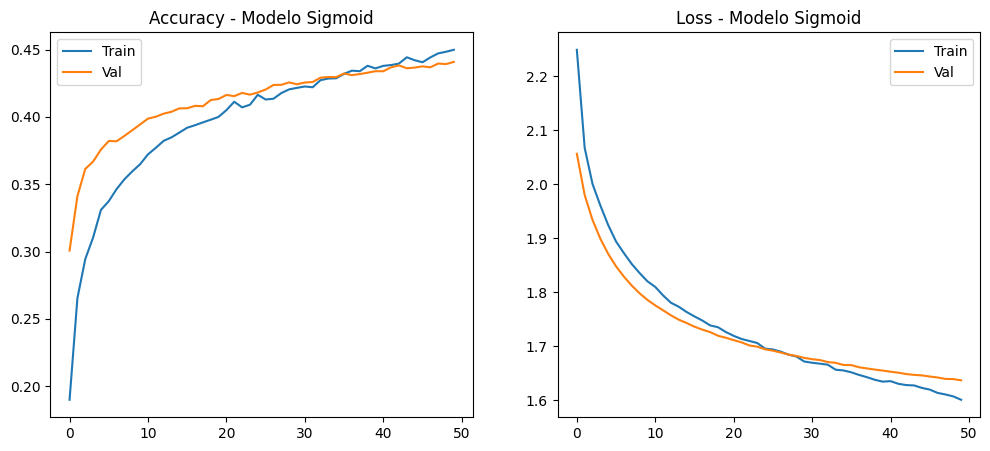

In [21]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_sigmoid.history['accuracy'], label='Train')
plt.plot(history_sigmoid.history['val_accuracy'], label='Val')
plt.title('Accuracy - Modelo Sigmoid')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_sigmoid.history['loss'], label='Train')
plt.plot(history_sigmoid.history['val_loss'], label='Val')
plt.title('Loss - Modelo Sigmoid')
plt.legend()

plt.show()

In [22]:
loss_base, acc_base = model_base.evaluate(x_test, y_test, verbose=0)
loss_reg, acc_reg = model_reg_final.evaluate(x_test, y_test, verbose=0)
loss_sigmoid, acc_sigmoid = model_sigmoid.evaluate(x_test, y_test, verbose=0)

print("\n RESULTADOS FINALES\n")

print(f"{'Modelo':<20}{'Loss':<15}{'Accuracy'}")
print("-"*40)
print(f"{'Base':<20}{loss_base:<15.4f}{acc_base:.4f}")
print(f"{'Regularizado':<20}{loss_reg:<15.4f}{acc_reg:.4f}")
print(f"{'Sigmoid':<20}{loss_sigmoid:<15.4f}{acc_sigmoid:.4f}")


 RESULTADOS FINALES

Modelo              Loss           Accuracy
----------------------------------------
Base                2.4326         0.5063
Regularizado        1.3368         0.5796
Sigmoid             1.6235         0.4416


##  Análisis comparativo de precisión en validación

La gráfica de comparación de *accuracy* en el conjunto de validación permite evaluar el impacto de la arquitectura, la regularización y las funciones de activación en la capacidad de generalización del modelo.

Se identifican tres comportamientos claramente diferenciados:

---

###  Modelo Regularizado (ReLU)

Este modelo presenta el mejor desempeño general.

- Muestra un crecimiento sostenido del accuracy  
- Alcanza una precisión cercana al **59%**  
- Presenta estabilidad en las últimas épocas  

Esto indica que la combinación de:

- **Batch Normalization**  
- **Dropout**  
- **Regularización L2**  

permite mejorar la generalización y evitar el sobreajuste.

---

### Modelo Base (ReLU sin regularización)

Este modelo presenta un aprendizaje rápido en las primeras etapas, pero con limitaciones importantes:

- Aumento rápido del accuracy en las primeras épocas  
- Posterior estancamiento y oscilaciones  
- Degradación del rendimiento después de ~20 épocas  

Este comportamiento es característico del **overfitting**, donde el modelo aprende los datos de entrenamiento pero pierde capacidad de generalizar.

---

###  Modelo Sigmoid

Este modelo presenta el rendimiento más bajo del experimento:

- Aprendizaje lento  
- Curva de crecimiento más plana  
- Precisión máxima cercana al **44%**  

Esto se debe a:

- Problema de **gradiente desvanecido**  
- Saturación de la función sigmoide  
- Dificultad para entrenar redes profundas  

---

## Conclusiones del comparativo

### Superioridad de ReLU

Las funciones de activación tipo ReLU presentan un rendimiento significativamente superior, superando a Sigmoid en más de **15 puntos porcentuales** en accuracy.

---

###  Importancia de la regularización

La comparación entre el modelo base y el regularizado demuestra que:

- Sin regularización → sobreajuste temprano  
- Con regularización → aprendizaje más estable y generalizable  

Esto confirma que el uso de técnicas como Dropout y L2 es fundamental en redes densas.





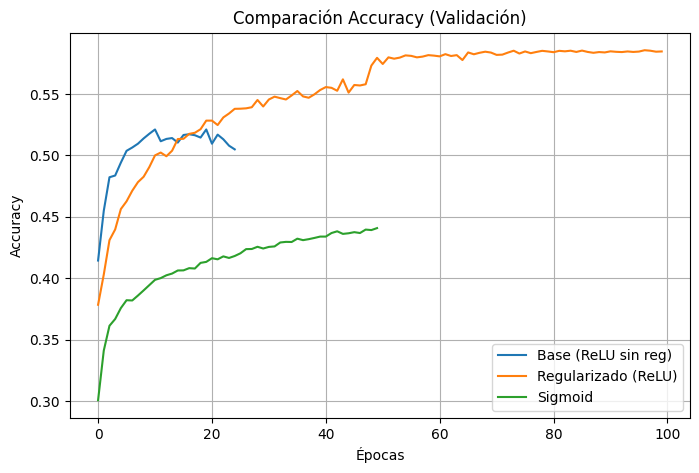

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_base.history['val_accuracy'], label='Base (ReLU sin reg)')
plt.plot(history.history['val_accuracy'], label='Regularizado (ReLU)')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')

plt.title('Comparación Accuracy (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

##  Justificación del uso de ReLU

Para los experimentos principales se seleccionó la función de activación **ReLU (Rectified Linear Unit)** debido a sus ventajas:

- Evita el problema del **gradiente desvanecido**  
- Permite una **convergencia más rápida**  
- Mejora el aprendizaje de relaciones no lineales  

---

##  Correspondencia de clases

Las clases del dataset CIFAR-10 están codificadas de la siguiente forma:

| Clase | Etiqueta |
|------|--------|
| 0 | avión |
| 1 | auto |
| 2 | pájaro |
| 3 | gato |
| 4 | ciervo |
| 5 | perro |
| 6 | rana |
| 7 | caballo |
| 8 | barco |
| 9 | camión |

---

##  Evaluación del modelo (Classification Report)

### Accuracy

- **Accuracy: 0.58 (58%)**

El modelo clasifica correctamente el 58% de las imágenes del conjunto de prueba.

---

###  Precision (Precisión)

Mide cuántas predicciones fueron correctas por clase.

- Buen desempeño en:
  - **Clase 1 (auto)** → 0.68  
  - **Clase 8 (barco)** → 0.68  

- Bajo desempeño en:
  - **Clase 3 (gato)** → 0.39  

---

###  Recall

Mide cuántos elementos reales fueron correctamente identificados.

- Alto recall en:
  - **Clase 8 (barco)** → 0.73  
  - **Clase 6 (rana)** → 0.66  

- Bajo recall en:
  - **Clase 2 (pájaro)** → 0.42  
  - **Clase 3 (gato)** → 0.41  

---

###  F1-score

Balance entre precisión y recall.

- Promedio general: **0.58**
- Mejores clases:
  - **barco (8)** → 0.70  
  - **auto (1)** → 0.68  

- Peores clases:
  - **gato (3)** → 0.40  

---

###  Macro vs Weighted Average

- **Macro avg:** 0.58 → promedio simple  
- **Weighted avg:** 0.58 → promedio ponderado  

Esto indica que el dataset está balanceado.

---

##  Interpretación general

- Buen rendimiento en clases con características más claras (**auto, barco, rana**)  
- Dificultad en clases visualmente similares (**gato, pájaro, perro**)  
- El modelo no presenta sesgo fuerte hacia una clase  



In [16]:
y_pred = model_reg_final.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

           0       0.66      0.63      0.65      1000
           1       0.68      0.68      0.68      1000
           2       0.50      0.42      0.46      1000
           3       0.39      0.41      0.40      1000
           4       0.51      0.53      0.52      1000
           5       0.50      0.47      0.48      1000
           6       0.61      0.66      0.63      1000
           7       0.64      0.64      0.64      1000
           8       0.68      0.73      0.70      1000
           9       0.61      0.63      0.62      1000

    accuracy                           0.58     10000
   macro avg       0.58      0.58      0.58     10000
weighted avg       0.58      0.58      0.58     10000



## Análisis de la Matriz de Confusión

La matriz de confusión permite evaluar el desempeño del modelo **clase por clase**, identificando tanto aciertos como errores específicos.  
A diferencia de métricas globales como el accuracy, esta herramienta revela las debilidades estructurales del clasificador.

---

##  1. Interpretación de la Diagonal Principal

La diagonal principal (de izquierda a derecha) representa los **aciertos del modelo (Verdaderos Positivos)**.

###  Clases con mejor desempeño
- Clase **8 (barco)** → 727 aciertos  
- Clase **1 (auto)** → 680 aciertos  
- Clase **6 (rana)** → 655 aciertos  

 Estas clases presentan características más diferenciables, lo que facilita su clasificación.

---

###  Clases con menor desempeño
- Clase **3 (gato)** → 405 aciertos  
- Clase **2 (pájaro)** → 425 aciertos  

 El modelo tiene dificultades para extraer características distintivas en estas categorías.

---

##  2. Análisis de Confusiones Críticas

Los valores fuera de la diagonal indican **errores de clasificación**.  
Estos errores no son aleatorios, sino que siguen patrones visuales:

---

### Confusión entre clases similares

- **Clase 5 (perro) → clase 3 (gato)** → 240 casos  
- **Clase 3 (gato) → clase 5 (perro)** → 193 casos  

Existe una **ambigüedad bidireccional**, lo que indica que el modelo no logra diferenciar correctamente estas clases.

---

###  Confusión en transporte

- **Clase 9 (camión) → clase 1 (auto)** → 164 casos  

 Ambas clases comparten características estructurales similares.

---

### Confusión por contexto visual

- **Clase 0 (avión) → clase 8 (barco)** → 129 casos  

Posible influencia del fondo (cielo/mar), lo que genera confusión en el modelo.

---

##  3. Implicaciones Negativas

### Sesgo morfológico

Los errores se concentran en clases con **características visuales similares**, lo que indica que el modelo:

- No captura detalles finos  
- Se basa en patrones generales (color, forma global)  
- Tiene limitaciones para diferenciar estructuras complejas  

---

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


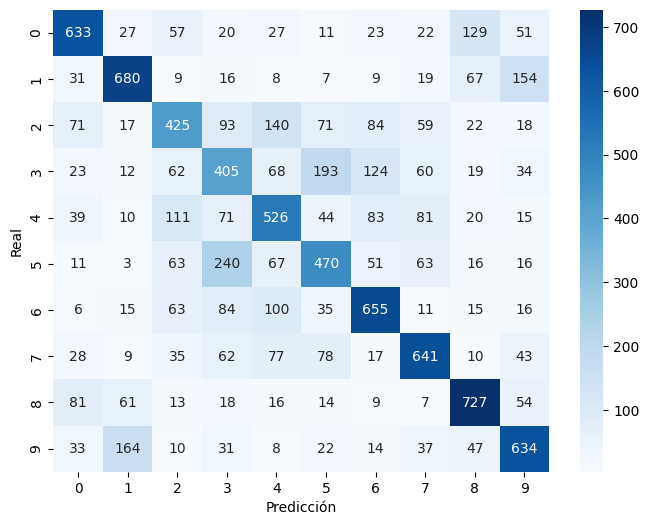

In [23]:
y_pred = model_reg_final.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

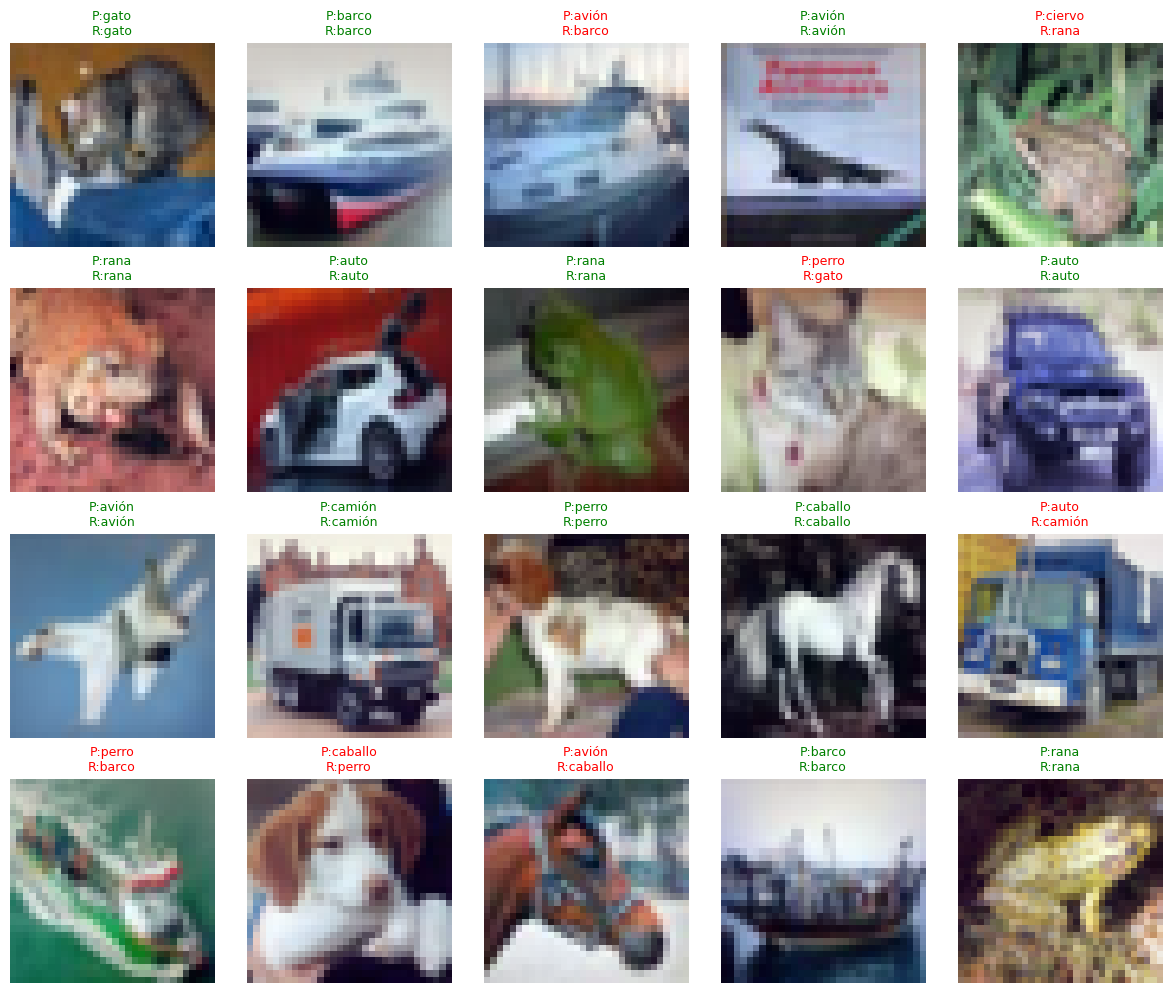

In [26]:
plt.figure(figsize=(12, 10))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    #  Desnormalizar correctamente
    img = x_test[i] * std + mean

    #  Normalizar para mostrar
    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)

    pred = class_names[y_pred_classes[i]]
    real = class_names[y_test[i].item()]

    color = "green" if pred == real else "red"

    plt.title(f"P:{pred}\nR:{real}", fontsize=9, color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Análisis Cualitativo de Predicciones Individuales

La visualización de predicciones sobre imágenes del conjunto de prueba permite realizar un análisis cualitativo del desempeño del modelo.

En cada imagen:
- **P:** Predicción del modelo  
- **R:** Etiqueta real (ground truth)  

Este análisis complementa las métricas cuantitativas, permitiendo identificar patrones de aciertos y errores.

---

##  1. Aciertos significativos (etiquetas en verde)

El modelo demuestra un buen desempeño en clases con características visuales claras y diferenciables:

### Vehículos
- Correcta identificación de:
  - **auto (1)**  
  - **camión (9)**  
  - **avión (0)**  
  - **barco (8)**  

Esto sugiere que el modelo ha aprendido:
- Formas geométricas simples  
- Relación con el fondo (ej: cielo o mar)  

---

###  Animales con rasgos distintivos
- Buen desempeño en:
  - **rana (6)**  
  - **caballo (7)**  

 Especialmente cuando:
- El objeto está centrado  
- Existe buen contraste con el fondo  

---

## 2. Análisis de errores (etiquetas en rojo)

Los errores revelan limitaciones estructurales del modelo MLP:

---

###  Confusión entre animales similares

- **perro (5) ↔ gato (3)**  
- **ciervo (4) ↔ rana (6)**  

El modelo:
- No detecta partes específicas (orejas, patas, hocico)  
- Se basa en **texturas y colores globales**  

---

###  Errores de contexto

- Ejemplo: **barco → perro**

Indica que:
- El modelo no comprende el objeto  
- Solo reconoce patrones de píxeles similares  

---

### Ambigüedad en transporte

- **auto (1) ↔ camión (9)**  

 Problema:
- No distingue escala ni detalles estructurales  
- Solo identifica forma general  

---

##  3. Conclusión del análisis cualitativo

La inspección visual confirma que el modelo presenta:

- Buen desempeño en imágenes simples  
- Dificultad en escenarios complejos  
- Baja capacidad para distinguir detalles finos  

Esto se debe a que:

- La arquitectura MLP **no captura relaciones espaciales**  
- No detecta patrones jerárquicos  
- Depende de la posición exacta de los píxeles  

---



## Conclusión

> El análisis cualitativo confirma que el modelo MLP presenta limitaciones al clasificar imágenes complejas, especialmente en clases con alta similitud visual. Esto justifica la necesidad de utilizar arquitecturas convolucionales para mejorar la capacidad de generalización.

#  Conclusión General y Recomendaciones

El desarrollo de este proyecto permitió implementar y analizar en profundidad una red neuronal multicapa (MLP) aplicada a la clasificación de imágenes del dataset CIFAR-10, abordando de manera completa el ciclo de vida de un modelo de aprendizaje profundo: desde la preparación de datos hasta la evaluación e interpretación de resultados.

En una primera etapa, se evidenció que un modelo base sin regularización tiende rápidamente al **sobreajuste (overfitting)**, mostrando una alta precisión en entrenamiento pero un bajo rendimiento en validación. Esto puso de manifiesto la importancia de incorporar técnicas que controlen la complejidad del modelo.

La implementación de estrategias como **Dropout, Batch Normalization y regularización L2** permitió mejorar significativamente la estabilidad del entrenamiento, reduciendo la brecha entre entrenamiento y validación, y logrando un rendimiento cercano al **58–59% de accuracy**. Esto confirma que una correcta configuración de hiperparámetros y técnicas de regularización es clave para obtener modelos más robustos.

Por otra parte, el análisis de funciones de activación demostró empíricamente que **ReLU es considerablemente superior a Sigmoid** en este tipo de problemas. Mientras que ReLU facilitó una convergencia rápida y eficiente, la función Sigmoid presentó problemas de **gradiente desvanecido**, limitando la capacidad de aprendizaje del modelo y generando un claro caso de subajuste.

El estudio de métricas como **precision, recall y F1-score**, junto con la matriz de confusión y la visualización de predicciones, permitió identificar patrones de error consistentes. En particular, el modelo presenta dificultades en clases con alta similitud visual (como *gato-perro* o *auto-camión*), lo que evidencia que la red no logra capturar características complejas o detalles estructurales finos.

---

## Limitaciones identificadas

A partir del análisis realizado, se identifican las siguientes limitaciones:

- El modelo MLP **no aprovecha la estructura espacial de las imágenes**
- Dificultad para capturar patrones locales (bordes, texturas)
- Dependencia de la posición exacta de los píxeles
- Presencia de un techo de rendimiento cercano al 60%

Estas limitaciones son propias de las redes densas cuando se aplican a problemas de visión computacional.

---

##  Recomendaciones de mejora

Con base en los resultados obtenidos, se proponen las siguientes mejoras:

###  1. Implementar Redes Neuronales Convolucionales (CNN)
Permitiría:
- Detectar características espaciales
- Reducir errores entre clases similares
- Aumentar significativamente la precisión

---

###  2. Aplicar Data Augmentation
- Rotaciones, flips, zoom
- Mejora la capacidad de generalización
- Reduce el overfitting

---

###  3. Optimización de hiperparámetros
- Ajuste fino del learning rate
- Experimentación con distintos batch sizes
- Uso de optimizadores más avanzados

---

###  4. Evaluación más profunda
- Análisis por clase más detallado
- Uso de matriz de confusión normalizada
- Estudio de errores críticos

---

##  Reflexión final

El proyecto demuestra que el rendimiento de un modelo no depende únicamente de su entrenamiento, sino de una correcta combinación entre:

- Arquitectura  
- Función de activación  
- Técnicas de regularización  
- Preprocesamiento de datos  

Si bien el modelo desarrollado cumple con los objetivos planteados y logra resultados aceptables, también evidencia que la elección de la arquitectura es determinante para el éxito en problemas complejos.

